In [3]:
import json
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt
# import seaborn as sns

In [6]:
results_path = Path('linear_readout_weights')

val_outfiles = list(results_path.glob('*_val_results.json'))

results = []
for outfile in val_outfiles:
    layer_idx = outfile.stem.split('_')[1]
    with open(outfile, 'r') as f:
        val_results = json.load(f)
    val_results['layer_idx'] = layer_idx
    results.append(val_results)

results_df = pd.DataFrame(results)

In [7]:
results_df

,val_loss,val_acc,val_labels,val_preds,layer_idx
0,2.859484,0.175228,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[25, 1, 47, 28, 64, 46, 54, 35, 30, 11, 38, 19...",0
1,2.649825,0.192646,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[25, 33, 48, 34, 45, 65, 55, 36, 34, 10, 39, 2...",1
2,2.754322,0.168570,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[10, 1, 48, 33, 46, 65, 58, 36, 34, 11, 39, 23...",2
3,2.798044,0.181727,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[10, 1, 46, 33, 46, 44, 52, 36, 0, 11, 39, 23,...",3
4,2.797756,0.174762,"[26, 2, 47, 19, 60, 44, 55, 0, 29, 10, 39, 21,...","[10, 1, 47, 31, 45, 62, 55, 34, 31, 17, 39, 23...",4


In [11]:
def azim_to_label(azim):
    return np.array((azim / 5), dtype=np.int64)

def label_to_azim(label):
    return np.array((label * 5), dtype=np.int64)

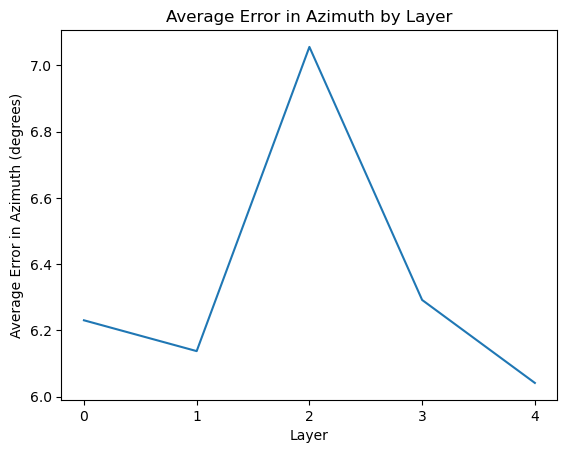

In [ ]:
# plot the average error in azimuth degrees for each layer
to_plot = {}
for layer_idx in results_df['layer_idx'].unique():
    layer_results = results_df[results_df['layer_idx'] == layer_idx]
    azim_labels = [label_to_azim(label) for label in layer_results['val_labels']]
    azim_preds = [label_to_azim(pred) for pred in layer_results['val_preds']]
    diffs = [abs(label - pred) for label, pred in zip(azim_labels, azim_preds)]
    avg_diff = np.mean(diffs)
    to_plot[layer_idx] = avg_diff

# plot avg diffs by layer
plt.figure(figsize=(10, 6))
plt.plot(list(to_plot.keys()), list(to_plot.values()))
plt.xlabel('Layer')
plt.ylabel('Average Error in Azimuth (degrees)')
plt.title('Average Error in Azimuth by Layer')
plt.show()

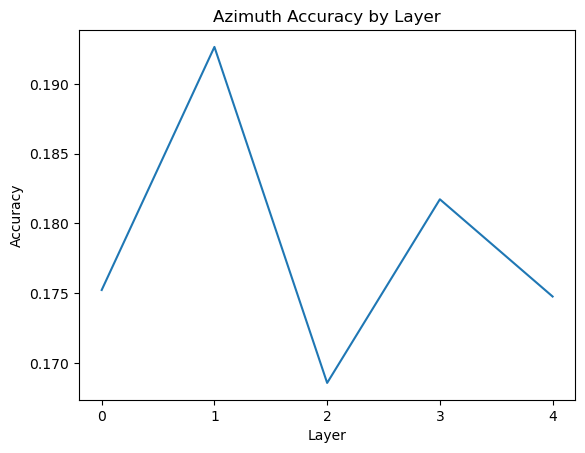

In [14]:
# plot accuracy by layer
plt.plot(results_df['layer_idx'], results_df['val_acc'])
plt.xlabel('Layer')
plt.ylabel('Accuracy')
plt.title('Azimuth Accuracy by Layer')
plt.show()
